# ODM 2025 – Exercise Sheet 6: Vergleich von Multi-Objective Optimization Algorithmen

In diesem Notebook werden verschiedene MOO-Algorithmen auf die binäre bi-objektive Funktion (Function7) angewendet und anhand verschiedener Qualitätsmetriken verglichen:

**Algorithmen:**
- NSGA-II (Non-dominated Sorting Genetic Algorithm II)
- SMS-EMOA (S-Metric Selection EMOA)
- MOEA/D (Multi-Objective Evolutionary Algorithm based on Decomposition)

**Metriken:**
- Hypervolume (HV)
- Inverted Generational Distance (IGD)
- Generational Distance (GD)


## VPN Reminder

The black-box service is only available when **connected to the Uni Münster VPN**!


## 1. Setup und Imports


In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
import time
import pandas as pd

SEED = 42
np.random.seed(SEED)


In [2]:
class BlackBox:
    def __init__(self, token: int, endpoint: str = 'http://ls-stat-ml.uni-muenster.de:7300/'):
        self.endpoint = endpoint
        self.token = token
        self.evaluation_count = 0

    def evaluate(self, objective: str, parameters: list) -> float:
        r = requests.post(url=self.endpoint + "compute/" + objective,
                          json={"parameters": [str(v) for v in parameters], "token": self.token})
        self.evaluation_count += 1
        if r.status_code == 200:
            return r.json()
        else:
            print(parameters)
            raise ValueError(r)

    def reset_counter(self):
        self.evaluation_count = 0


In [3]:
# TODO: Change to your group number!
group_number = 11

bb = BlackBox(token=group_number)


## 2. PyMOO Setup


In [4]:
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.sms import SMSEMOA
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.operators.crossover.hux import HalfUniformCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
from pymoo.indicators.gd import GD


In [5]:
class BinaryBiObjectiveProblem(Problem):
    def __init__(self, blackbox: BlackBox):
        super().__init__(n_var=30, 
                         n_obj=2, 
                         n_constr=0, 
                         type_var=np.bool_)
        self.blackbox = blackbox

    def _evaluate(self, X, out, *args, **kwargs):            
        n_individuals = X.shape[0]
        F = np.zeros((n_individuals, self.n_obj))

        for i, individual in enumerate(X):
            parameters = [int(x is True) for x in individual.tolist()]
            y = self.blackbox.evaluate("Function7", parameters)

            F[i, 0] = y[0]
            F[i, 1] = y[1]
                        
        out["F"] = F


## 3. Algorithmus-Konfigurationen

Wir definieren die drei MOO-Algorithmen mit vergleichbaren Parametern:

- **NSGA-II**: Verwendet Non-dominated Sorting (NDS) und Crowding Distance (CD)
- **SMS-EMOA**: Verwendet Hypervolume-Beitrag als Selektionskriterium  
- **MOEA/D**: Zerlegt das Problem mittels Tchebycheff-Skalarisierung


In [6]:
POP_SIZE = 50
N_GENERATIONS = 50

TERMINATION = get_termination("n_gen", N_GENERATIONS)

print(f"Population Size: {POP_SIZE}")
print(f"Number of Generations: {N_GENERATIONS}")
print(f"Seed: {SEED}")


Population Size: 50
Number of Generations: 50
Seed: 42


In [7]:
def create_nsga2():
    return NSGA2(
        pop_size=POP_SIZE,
        sampling=BinaryRandomSampling(),
        crossover=HalfUniformCrossover(),
        mutation=BitflipMutation(),
        eliminate_duplicates=True
    )


def create_sms_emoa():
    return SMSEMOA(
        pop_size=POP_SIZE,
        sampling=BinaryRandomSampling(),
        crossover=HalfUniformCrossover(),
        mutation=BitflipMutation(),
        eliminate_duplicates=True
    )


def create_moead():
    ref_dirs = get_reference_directions("uniform", 2, n_partitions=POP_SIZE-1)
    return MOEAD(
        ref_dirs=ref_dirs,
        n_neighbors=15,
        sampling=BinaryRandomSampling(),
        crossover=HalfUniformCrossover(),
        mutation=BitflipMutation()
    )


## 4. Optimierung durchführen

Wir führen jeden Algorithmus mit dem gleichen Seed aus, um Reproduzierbarkeit zu gewährleisten.


In [8]:
def run_optimization(algorithm, algorithm_name: str, seed: int = SEED):
    problem = BinaryBiObjectiveProblem(bb)
    bb.reset_counter()
    
    print(f"\n{'='*60}")
    print(f"Running {algorithm_name}...")
    print(f"{'='*60}")
    
    start_time = time.time()
    
    result = minimize(
        problem,
        algorithm,
        TERMINATION,
        seed=seed,
        verbose=False
    )
    
    elapsed_time = time.time() - start_time
    evaluations = bb.evaluation_count
    
    print(f"Completed in {elapsed_time:.2f} seconds")
    print(f"Total function evaluations: {evaluations}")
    print(f"Number of non-dominated solutions: {len(result.F)}")
    
    return {
        'name': algorithm_name,
        'result': result,
        'time': elapsed_time,
        'evaluations': evaluations,
        'X': result.X,
        'F': result.F
    }


In [9]:
results = {}

results['NSGA-II'] = run_optimization(create_nsga2(), 'NSGA-II', seed=SEED)
results['SMS-EMOA'] = run_optimization(create_sms_emoa(), 'SMS-EMOA', seed=SEED)
results['MOEA/D'] = run_optimization(create_moead(), 'MOEA/D', seed=SEED)



Running NSGA-II...
Completed in 140.44 seconds
Total function evaluations: 2500
Number of non-dominated solutions: 50

Running SMS-EMOA...
Completed in 137.85 seconds
Total function evaluations: 2500
Number of non-dominated solutions: 50

Running MOEA/D...
Completed in 139.97 seconds
Total function evaluations: 2500
Number of non-dominated solutions: 50


## 5. Qualitätsmetriken berechnen

### Metriken:

1. **Hypervolume (HV)**: Misst das Volumen des dominierten Raums zwischen der Pareto-Front-Approximation und einem Referenzpunkt. **Höher ist besser.**

2. **Inverted Generational Distance (IGD)**: Mittlere Distanz von der Referenzmenge zur approximierten Menge. Misst sowohl Konvergenz als auch Diversität. **Niedriger ist besser.**

3. **Generational Distance (GD)**: Mittlere Distanz von der approximierten Menge zur Referenzmenge. Misst primär Konvergenz. **Niedriger ist besser.**


In [20]:
all_fronts = np.vstack([r['F'] for r in results.values()])

def get_nondominated(F):
    is_dominated = np.zeros(len(F), dtype=bool)
    for i in range(len(F)):
        for j in range(len(F)):
            if i != j:
                if np.all(F[j] <= F[i]) and np.any(F[j] < F[i]):
                    is_dominated[i] = True
                    break
    return F[~is_dominated]

combined_reference = get_nondominated(all_fronts)
print(f"Combined reference set size: {len(combined_reference)}")

ref_point = np.array([10000.0, 10000.0])
print(f"Reference point for Hypervolume: {ref_point}")


Combined reference set size: 133
Reference point for Hypervolume: [10000. 10000.]


In [23]:
def calculate_metrics(F, reference_set, ref_point):
    hv_indicator = HV(ref_point=ref_point)
    igd_indicator = IGD(reference_set)
    gd_indicator = GD(reference_set)
    
    hv = hv_indicator(F)
    igd = igd_indicator(F)
    gd = gd_indicator(F)
    
    return {
        'Hypervolume': hv,
        'IGD': igd,
        'GD': gd
    }


In [24]:
metrics_results = {}

for name, data in results.items():
    metrics = calculate_metrics(data['F'], combined_reference, ref_point)
    metrics['Time (s)'] = data['time']
    metrics['Evaluations'] = data['evaluations']
    metrics['Solutions'] = len(data['F'])
    metrics_results[name] = metrics


## 6. Ergebnisse


In [25]:
metrics_df = pd.DataFrame(metrics_results).T
metrics_df = metrics_df[['Solutions', 'Evaluations', 'Time (s)', 'Hypervolume', 'IGD', 'GD']]

print("\n" + "="*80)
print("VERGLEICH DER MOO-ALGORITHMEN")
print("="*80)
print(f"\nParameter: Population={POP_SIZE}, Generationen={N_GENERATIONS}, Seed={SEED}")
print("\n")
display(metrics_df.round(4))



VERGLEICH DER MOO-ALGORITHMEN

Parameter: Population=50, Generationen=50, Seed=42




,Solutions,Evaluations,Time (s),Hypervolume,IGD,GD
NSGA-II,50.0,2500.0,140.4360,3.105246e+06,50.8114,0.2648
SMS-EMOA,50.0,2500.0,137.8547,3.013340e+06,84.8458,0.0426
MOEA/D,50.0,2500.0,139.9657,3.255405e+06,143.9661,0.5436


In [27]:
print("\n" + "="*80)
print("INTERPRETATION DER METRIKEN")
print("="*80)

best_hv = metrics_df['Hypervolume'].idxmax()
best_igd = metrics_df['IGD'].idxmin()
best_gd = metrics_df['GD'].idxmin()

print(f"\n• Bester Hypervolume (höher = besser): {best_hv} ({metrics_df.loc[best_hv, 'Hypervolume']:.4f})")
print(f"• Beste IGD (niedriger = besser): {best_igd} ({metrics_df.loc[best_igd, 'IGD']:.4f})")
print(f"• Beste GD (niedriger = besser): {best_gd} ({metrics_df.loc[best_gd, 'GD']:.4f})")



INTERPRETATION DER METRIKEN

• Bester Hypervolume (höher = besser): MOEA/D (3255404.6403)
• Beste IGD (niedriger = besser): NSGA-II (50.8114)
• Beste GD (niedriger = besser): SMS-EMOA (0.0426)


## 7. Visualisierung der Pareto-Fronten


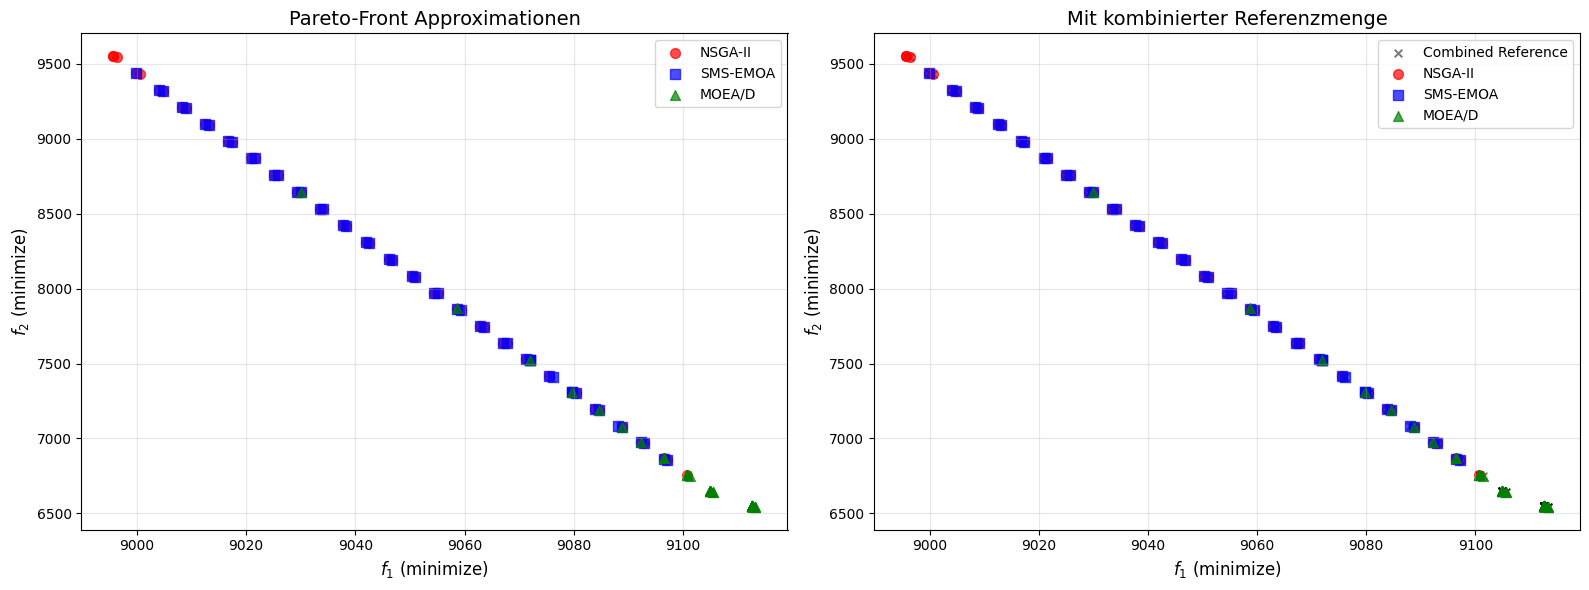

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'NSGA-II': 'red', 'SMS-EMOA': 'blue', 'MOEA/D': 'green'}
markers = {'NSGA-II': 'o', 'SMS-EMOA': 's', 'MOEA/D': '^'}

ax1 = axes[0]
for name, data in results.items():
    F = data['F']
    ax1.scatter(F[:, 0], F[:, 1], 
                c=colors[name], 
                marker=markers[name], 
                label=name, 
                alpha=0.7,
                s=50)

ax1.set_xlabel('$f_1$ (minimize)', fontsize=12)
ax1.set_ylabel('$f_2$ (minimize)', fontsize=12)
ax1.set_title('Pareto-Front Approximationen', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.scatter(combined_reference[:, 0], combined_reference[:, 1], 
            c='black', marker='x', s=30, label='Combined Reference', alpha=0.5)

for name, data in results.items():
    F = data['F']
    ax2.scatter(F[:, 0], F[:, 1], 
                c=colors[name], 
                marker=markers[name], 
                label=name, 
                alpha=0.7,
                s=50)

ax2.set_xlabel('$f_1$ (minimize)', fontsize=12)
ax2.set_ylabel('$f_2$ (minimize)', fontsize=12)
ax2.set_title('Mit kombinierter Referenzmenge', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


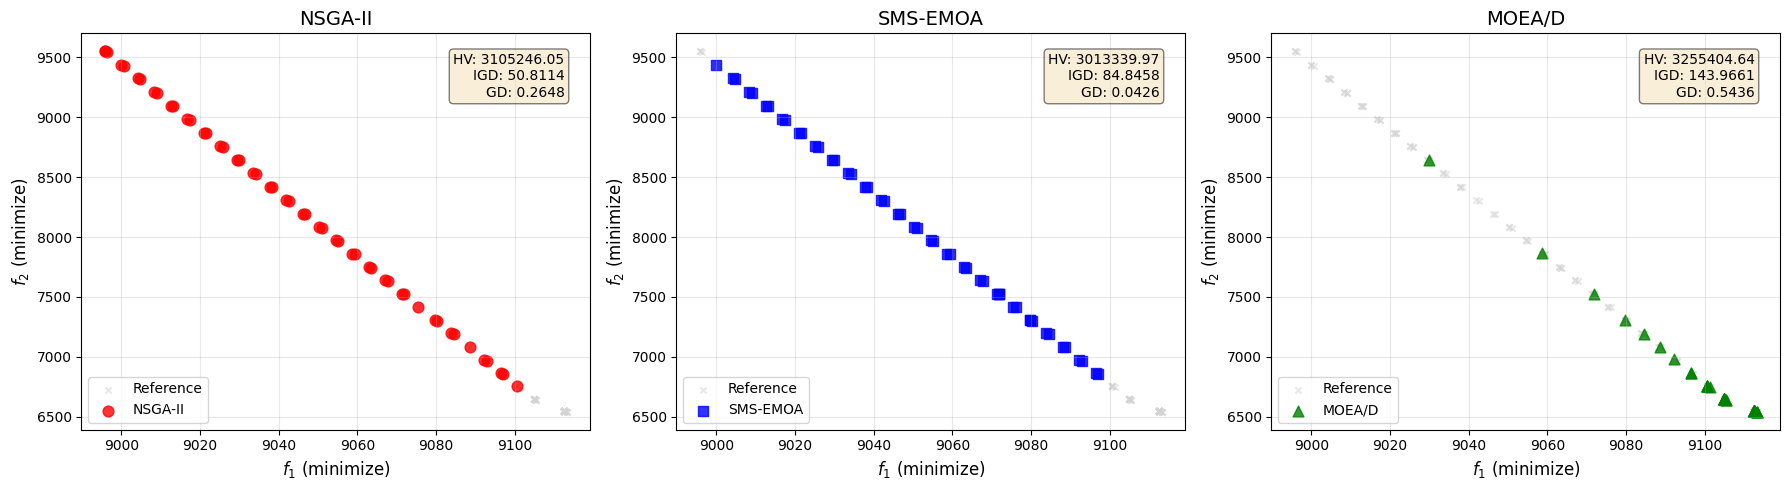

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    ax = axes[idx]
    F = data['F']
    
    ax.scatter(combined_reference[:, 0], combined_reference[:, 1], 
               c='lightgray', marker='x', s=20, label='Reference', alpha=0.5)
    
    ax.scatter(F[:, 0], F[:, 1], 
               c=colors[name], 
               marker=markers[name], 
               label=name, 
               alpha=0.8,
               s=60)
    
    metrics = metrics_results[name]
    info_text = f"HV: {metrics['Hypervolume']:.2f}\nIGD: {metrics['IGD']:.4f}\nGD: {metrics['GD']:.4f}"
    ax.text(0.95, 0.95, info_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('$f_1$ (minimize)', fontsize=12)
    ax.set_ylabel('$f_2$ (minimize)', fontsize=12)
    ax.set_title(f'{name}', fontsize=14)
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Metriken-Vergleich (Balkendiagramm)


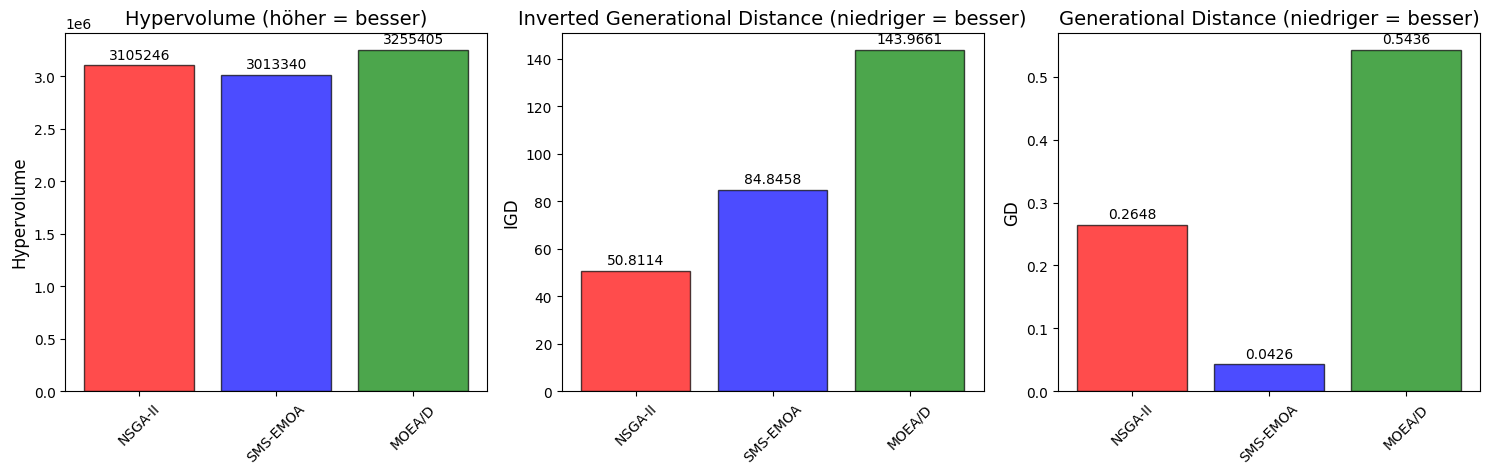

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

algorithms = list(results.keys())
bar_colors = [colors[alg] for alg in algorithms]

ax1 = axes[0]
hv_values = [metrics_results[alg]['Hypervolume'] for alg in algorithms]
bars1 = ax1.bar(algorithms, hv_values, color=bar_colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Hypervolume', fontsize=12)
ax1.set_title('Hypervolume (höher = besser)', fontsize=14)
ax1.tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, hv_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(hv_values)*0.01, 
             f'{val:.0f}', ha='center', va='bottom', fontsize=10)

ax2 = axes[1]
igd_values = [metrics_results[alg]['IGD'] for alg in algorithms]
bars2 = ax2.bar(algorithms, igd_values, color=bar_colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('IGD', fontsize=12)
ax2.set_title('Inverted Generational Distance (niedriger = besser)', fontsize=14)
ax2.tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, igd_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(igd_values)*0.01, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

ax3 = axes[2]
gd_values = [metrics_results[alg]['GD'] for alg in algorithms]
bars3 = ax3.bar(algorithms, gd_values, color=bar_colors, alpha=0.7, edgecolor='black')
ax3.set_ylabel('GD', fontsize=12)
ax3.set_title('Generational Distance (niedriger = besser)', fontsize=14)
ax3.tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, gd_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(gd_values)*0.01, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 9. Zusammenfassung


In [31]:
print("="*80)
print("ZUSAMMENFASSUNG")
print("="*80)

print("\n### Algorithmen-Beschreibung:")
print("""
1. NSGA-II (Non-dominated Sorting Genetic Algorithm II):
   - Verwendet Non-dominated Sorting (NDS) als primäres Selektionskriterium
   - Crowding Distance (CD) als sekundäres Kriterium für Diversität
   - (µ + µ) Strategie

2. SMS-EMOA (S-Metric Selection EMOA):
   - Steady-State (µ + 1) Strategie
   - Verwendet Hypervolume-Beitrag als Selektionskriterium
   - Entfernt Lösung mit kleinstem HV-Beitrag

3. MOEA/D (Multi-Objective EA based on Decomposition):
   - Zerlegt das Problem in skalare Teilprobleme mittels Gewichtsvektoren
   - Verwendet Tchebycheff-Ansatz zur Skalarisierung
   - Nachbarschaftsbasierter Lösungsaustausch
""")

print("### Metriken-Beschreibung:")
print("""
1. Hypervolume (HV):
   - Misst das dominierte Volumen zwischen Pareto-Front und Referenzpunkt
   - Berücksichtigt sowohl Konvergenz als auch Diversität
   - HÖHER ist BESSER

2. Inverted Generational Distance (IGD):
   - Mittlere Distanz von Referenzpunkten zur approximierten Menge
   - Misst Konvergenz UND Diversität
   - NIEDRIGER ist BESSER

3. Generational Distance (GD):
   - Mittlere Distanz von approximierten Lösungen zur Referenzmenge
   - Misst primär Konvergenz
   - NIEDRIGER ist BESSER
""")

print("### Finale Ergebnistabelle:")
display(metrics_df.round(4))


ZUSAMMENFASSUNG

### Algorithmen-Beschreibung:

1. NSGA-II (Non-dominated Sorting Genetic Algorithm II):
   - Verwendet Non-dominated Sorting (NDS) als primäres Selektionskriterium
   - Crowding Distance (CD) als sekundäres Kriterium für Diversität
   - (µ + µ) Strategie

2. SMS-EMOA (S-Metric Selection EMOA):
   - Steady-State (µ + 1) Strategie
   - Verwendet Hypervolume-Beitrag als Selektionskriterium
   - Entfernt Lösung mit kleinstem HV-Beitrag

3. MOEA/D (Multi-Objective EA based on Decomposition):
   - Zerlegt das Problem in skalare Teilprobleme mittels Gewichtsvektoren
   - Verwendet Tchebycheff-Ansatz zur Skalarisierung
   - Nachbarschaftsbasierter Lösungsaustausch

### Metriken-Beschreibung:

1. Hypervolume (HV):
   - Misst das dominierte Volumen zwischen Pareto-Front und Referenzpunkt
   - Berücksichtigt sowohl Konvergenz als auch Diversität
   - HÖHER ist BESSER

2. Inverted Generational Distance (IGD):
   - Mittlere Distanz von Referenzpunkten zur approximierten Menge
   - 

,Solutions,Evaluations,Time (s),Hypervolume,IGD,GD
NSGA-II,50.0,2500.0,140.4360,3.105246e+06,50.8114,0.2648
SMS-EMOA,50.0,2500.0,137.8547,3.013340e+06,84.8458,0.0426
MOEA/D,50.0,2500.0,139.9657,3.255405e+06,143.9661,0.5436


In [32]:
print("\n### Beste gefundene Lösungen (Extrempunkte):")

for name, data in results.items():
    F = data['F']
    X = data['X']
    
    best_f1_idx = np.argmin(F[:, 0])
    best_f2_idx = np.argmin(F[:, 1])
    
    print(f"\n{name}:")
    print(f"  Beste f1: {F[best_f1_idx, 0]:.2f} (f2: {F[best_f1_idx, 1]:.2f})")
    print(f"  Beste f2: {F[best_f2_idx, 1]:.2f} (f1: {F[best_f2_idx, 0]:.2f})")



### Beste gefundene Lösungen (Extrempunkte):

NSGA-II:
  Beste f1: 8995.69 (f2: 9551.09)
  Beste f2: 6757.53 (f1: 9100.69)

SMS-EMOA:
  Beste f1: 8999.89 (f2: 9438.02)
  Beste f2: 6857.70 (f1: 9097.16)

MOEA/D:
  Beste f1: 9029.96 (f2: 8645.10)
  Beste f2: 6542.16 (f1: 9113.29)
